In [13]:
import json
import re
import numpy as np
import matplotlib.pyplot as plt
import umap
from pathlib import Path
from scipy.spatial.distance import pdist, cdist, squareform
from scipy.stats import spearmanr
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors

data_path = "../outputs/%s/embeddings/"
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


/usr/local/lib/python3.12/dist-packages/IPython/core/magics/pylab.py:166: UserWarning: pylab import has clobbered these variables: ['seed', 'split']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


In [23]:
def get_relevance(proj_in, lab_in, ref_class, mode="uniform"):
    relevance = np.zeros((proj_in.shape[0],))
    relevance[lab_in[:,ref_class]==True] = 1
    return relevance

def DCG(relevance_descending, k=10):
    num = 2**relevance_descending[:k] - 1
    den = np.log2(1+np.arange(1,k+1))
    return (num/den).sum()

def nDCG(relevance, sorting_cossim, k=10):
    IDCGk = DCG(np.sort(relevance)[::-1], k=k)
    DCGk = DCG(relevance[sorting_cossim], k=k)
    return DCGk/IDCGk

def nDCGk_avg(proj_in, lab_in, ref_class, k=20):
    mask_class = (lab_in[:,ref_class]==True)
    res = []
    for idx_ref in range(mask_class.sum()):
        reference_proj = proj_in[(lab_in[:,ref_class]==True)][idx_ref]
        mask_ref = (np.arange(proj_in.shape[0])==np.argwhere((lab_in[:,ref_class]==True))[idx_ref])
        proj_search = proj_in[~mask_ref]
        cos_d  = cdist(reference_proj[None,:], proj_search,   metric='cosine')
        sorting_cossim = np.argsort(cos_d.squeeze())
        relevance = get_relevance(proj_search, lab_in[~mask_ref], ref_class)
        nDCG_samp = nDCG(relevance, sorting_cossim, k=k)
        res.append(nDCG_samp)
    #print(f"processed {idx_ref} ref proj from class {ref_class}")
    return (np.asarray(res).mean())

In [24]:
# Specify the run directory
run_directory='/users/ncerardi/sk030/projectG_supervised_latent_radiogals/outputs/run_both_closest_full_w10.0_s97_20260323_1533'
#run_directory='/users/ncerardi/sk030/projectG_supervised_latent_radiogals/outputs/run_both_closest_full_p0.5_s97_20260323_1750'

# Extract the run name from the directory path
run_name = Path(run_directory).name

# =============================================================================
# Cosine distance (embedding) vs Hamming distance (labels)
# =============================================================================
split     = 'test'
MAX_PAIRS = 300_000
seed      = 42
# =============================================================================

emb_dir = Path(f'../outputs/{run_name}/embeddings')
proj    = np.load(emb_dir / f'{split}_projections.npy')
labels  = np.load(emb_dir / f'{split}_labels.npy')

result_w10 = []
#Show results for all classes
for class_id in range(17):
    nDGG10_class = nDCGk_avg(proj, labels, class_id)
    result_w10.append(nDGG10_class)
    print(f"Class: {class_id} | nDCG@10 = {nDGG10_class}")

Class: 0 | nDCG@10 = 0.6095724004330709
Class: 1 | nDCG@10 = 0.7727983809879547
Class: 2 | nDCG@10 = 0.2941452463889124
Class: 3 | nDCG@10 = 0.22693771006281918
Class: 4 | nDCG@10 = 0.32555133969666933
Class: 5 | nDCG@10 = 0.3989310497671075
Class: 6 | nDCG@10 = 0.2120028294242554
Class: 7 | nDCG@10 = 0.21790560947278972
Class: 8 | nDCG@10 = 0.24107052530939146
Class: 9 | nDCG@10 = 0.08461368353003024
Class: 10 | nDCG@10 = 0.2691648031318575
Class: 11 | nDCG@10 = 0.311768389924037
Class: 12 | nDCG@10 = 0.07285895487577339
Class: 13 | nDCG@10 = 0.02607156539941476
Class: 14 | nDCG@10 = 0.0
Class: 15 | nDCG@10 = 0.039913290043683006
Class: 16 | nDCG@10 = 0.0


In [25]:
# Specify the run directory
run_directory='/users/ncerardi/sk030/projectG_supervised_latent_radiogals/outputs/run_test2_MSlr2_20260327_1703'
#run_directory='/users/ncerardi/sk030/projectG_supervised_latent_radiogals/outputs/run_both_closest_full_p0.5_s97_20260323_1750'

# Extract the run name from the directory path
run_name = Path(run_directory).name

# =============================================================================
# Cosine distance (embedding) vs Hamming distance (labels)
# =============================================================================
split     = 'test'
MAX_PAIRS = 300_000
seed      = 42
# =============================================================================

emb_dir = Path(f'../outputs/{run_name}/embeddings')
proj    = np.load(emb_dir / f'{split}_projections.npy')
labels  = np.load(emb_dir / f'{split}_labels.npy')

#Show results for all classes
for class_id in range(17):
    nDGG10_class = nDCGk_avg(proj, labels, class_id)
    print(f"Class: {class_id} | nDCG@10 = {nDGG10_class}")

Class: 0 | nDCG@10 = 0.5855703941580918
Class: 1 | nDCG@10 = 0.7992732704284989
Class: 2 | nDCG@10 = 0.2898475360401501
Class: 3 | nDCG@10 = 0.2034772710386484
Class: 4 | nDCG@10 = 0.29820494977986634
Class: 5 | nDCG@10 = 0.40298833115752514
Class: 6 | nDCG@10 = 0.19972574505454802
Class: 7 | nDCG@10 = 0.21079716498584966
Class: 8 | nDCG@10 = 0.23147414071778788
Class: 9 | nDCG@10 = 0.08921143345007225
Class: 10 | nDCG@10 = 0.23732180780877465
Class: 11 | nDCG@10 = 0.31408099153809604
Class: 12 | nDCG@10 = 0.11236595127968955
Class: 13 | nDCG@10 = 0.059189102199478656
Class: 14 | nDCG@10 = 0.0
Class: 15 | nDCG@10 = 0.06529243269124588
Class: 16 | nDCG@10 = 0.0


In [26]:
# Specify the run directory
run_directory='/users/ncerardi/sk030/projectG_supervised_latent_radiogals/outputs/run_both_closest_full_w1.0_s97_20260323_1510'
#run_directory='/users/ncerardi/sk030/projectG_supervised_latent_radiogals/outputs/run_both_closest_full_p0.5_s97_20260323_1750'

# Extract the run name from the directory path
run_name = Path(run_directory).name

# =============================================================================
# Cosine distance (embedding) vs Hamming distance (labels)
# =============================================================================
split     = 'test'
MAX_PAIRS = 300_000
seed      = 42
# =============================================================================

emb_dir = Path(f'../outputs/{run_name}/embeddings')
proj    = np.load(emb_dir / f'{split}_projections.npy')
labels  = np.load(emb_dir / f'{split}_labels.npy')

result_w1 = []
#Show results for all classes
for class_id in range(17):
    nDGG10_class = nDCGk_avg(proj, labels, class_id)
    result_w1.append(nDGG10_class)
    print(f"Class: {class_id} | nDCG@10 = {nDGG10_class}")

Class: 0 | nDCG@10 = 0.5965759061524253
Class: 1 | nDCG@10 = 0.7572913521596008
Class: 2 | nDCG@10 = 0.2778148373999503
Class: 3 | nDCG@10 = 0.22859612307679644
Class: 4 | nDCG@10 = 0.3308460078228516
Class: 5 | nDCG@10 = 0.3959711152487662
Class: 6 | nDCG@10 = 0.20177921088100703
Class: 7 | nDCG@10 = 0.20951818872889957
Class: 8 | nDCG@10 = 0.28083451344562094
Class: 9 | nDCG@10 = 0.11273753991063057
Class: 10 | nDCG@10 = 0.26616185669785164
Class: 11 | nDCG@10 = 0.3283528156588872
Class: 12 | nDCG@10 = 0.11325430359094106
Class: 13 | nDCG@10 = 0.041302470471699534
Class: 14 | nDCG@10 = 0.0
Class: 15 | nDCG@10 = 0.06634843592687541
Class: 16 | nDCG@10 = 0.030169168986079343


In [27]:
# Specify the run directory
run_directory='/users/ncerardi/sk030/projectG_supervised_latent_radiogals/outputs/run_both_closest_full_w0.01_s97_20260323_1436'

# Extract the run name from the directory path
run_name = Path(run_directory).name

# =============================================================================
# Cosine distance (embedding) vs Hamming distance (labels)
# =============================================================================
split     = 'test'
MAX_PAIRS = 300_000
seed      = 42
# =============================================================================

emb_dir = Path(f'../outputs/{run_name}/embeddings')
proj    = np.load(emb_dir / f'{split}_projections.npy')
labels  = np.load(emb_dir / f'{split}_labels.npy')

result_w01 = []
#Show results for all classes
for class_id in range(17):
    nDGG10_class = nDCGk_avg(proj, labels, class_id)
    result_w01.append(nDGG10_class)
    print(f"Class: {class_id} | nDCG@10 = {nDGG10_class}")
    

Class: 0 | nDCG@10 = 0.4341901060535874
Class: 1 | nDCG@10 = 0.708329267860832
Class: 2 | nDCG@10 = 0.206953755510694
Class: 3 | nDCG@10 = 0.10004779719719986
Class: 4 | nDCG@10 = 0.24640803326704502
Class: 5 | nDCG@10 = 0.30852341103307285
Class: 6 | nDCG@10 = 0.16867621492122087
Class: 7 | nDCG@10 = 0.1874942937058689
Class: 8 | nDCG@10 = 0.20761069635977952
Class: 9 | nDCG@10 = 0.06797481555805673
Class: 10 | nDCG@10 = 0.19895580938624502
Class: 11 | nDCG@10 = 0.2991288803640038
Class: 12 | nDCG@10 = 0.08503680226879969
Class: 13 | nDCG@10 = 0.02224347133655308
Class: 14 | nDCG@10 = 0.0
Class: 15 | nDCG@10 = 0.04188222401372784
Class: 16 | nDCG@10 = 0.0


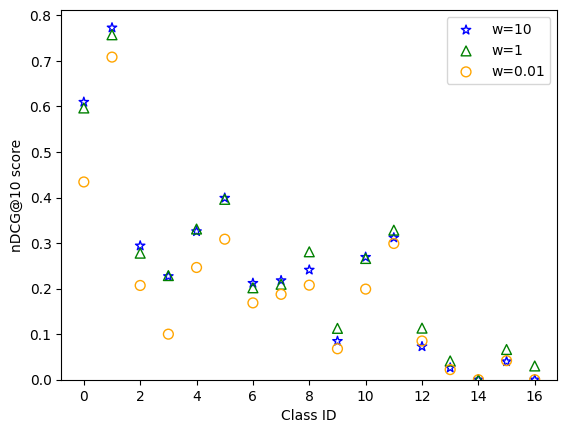

In [33]:
# Make a plot

scatter(np.arange(17), result_w10, label="w=10", s=50, marker='*', facecolor="none", edgecolor="b")
scatter(np.arange(17), result_w1, label="w=1", s=50, marker='^', facecolor="none", edgecolor="g")
scatter(np.arange(17), result_w01, label="w=0.01", s=50, marker='o', facecolor="none", edgecolor="orange")
xlabel("Class ID")
ylabel("nDCG@10 score")
ylim([0, None])
legend()
